# Gaussian Process tool

This notebook is a walkthrough for the pipeline used by the GP reconstruction code

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Settings

Here we specify the fixed settings of the reconstruction, namely the number and distribution of the $x$ points where the reconstruction is performed

In [3]:
N_recon = 5
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

# Create data to be reconstructed

Here we simulate data and errors for a completely made up observable

$$f(x) = \sum_{i=0}^N{a_ix^i}$$

where $N$ is the order of the polynomial and $a_i$ are the parameters controlling the $x$ trend of the observable

### Data settings

Settings controlling the data quality: number of measurements and their error

In [4]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

### Theory model

Here we specify the order of the polynomial observable and the fiducial values of its parameters

In [5]:
order = 1
fiducial = {'a0': 3,
            'a1': -1,
            #'a2': 5,
            #'a3': -0.1
           }

from parametric_approach.polynomial import PolynomialFit
theory = PolynomialFit(None,None,order=order)
theory_model = lambda x: theory.generate(x,[float(par) for par in fiducial.values()])

### Data generation

In [6]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model(dataset['x'])['f']
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

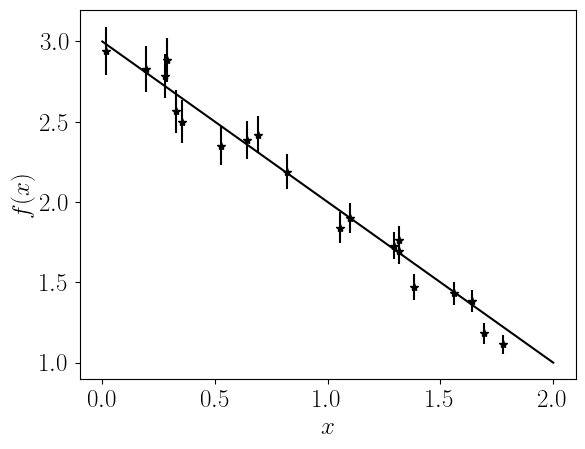

In [7]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
if theory_model != None:
    plt.plot(xplot,theory_model(xplot)['f'],color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Gaussian process

blablabla

In [8]:
from GaussianProcess.engine import GPCalculator

In [9]:
available_kernels = ['RBF','MATERN3/2','MATERN5/2']

## Simple run

The GPCalculator class can be initialized by giving as input the dataset and the covariance matrix 
for the function to reconstruct, together with the selected kernel.

After that, one can obtain a reconstruction straightforwardly by specifying the values of the kernel's hyperparameters (and nsteps **CHECK**)

The output of the reconstruction method is the mean values of the function at given points and the covariance of the predicted values.

This is not done only for the function itself, but also for its derivatives (up to the second when possible) and its integral.
For the latter, we need to specify the starting point of the integral and the number of steps taken.

**WARNING: SOMETHING WEIRD HAPPENING WITH THE SECOND DERIVATIVES IN MATERN KERNELS... REMOVING THEM FOR NOW!**

In [10]:
l     = 1
sigma = 1
integral_start = 0.
n_int_steps = 50

In [11]:
dfs = []
for kernel in available_kernels:
    tini = time()
    gp = GPCalculator(dataset,covmat,kernel_type=kernel)
    mu,cov = gp.predict_at_params(x_recon,l,sigma,integral_start,n_int_steps)
    
    #Unpacking results in human format (this is done in the code with the full approach)
    results = gp._unpack(mu,cov,x_recon)
    mean_df = pd.DataFrame({'x':x_recon}|results['means'])
    
    mean_df['Kernel'] = kernel 
        
    cols = []
    for func in results['means'].keys():
        cols = cols+['{}_{}'.format(func,ind) for ind in range(len(x_recon))]
    covmat_df = pd.DataFrame(cov,columns=cols,index=cols)
    
    for func in possible_derivatives:
        cov = covmat_df[[func+'_{}'.format(ind) for ind in range(N_recon)]]
        cov = cov.drop(index=[ind for ind in cov.index if ind not in [func+'_{}'.format(ind) for ind in range(N_recon)]])
        mean_df[func+'_err'] = np.sqrt(np.diag(cov))

    #TEMPORARY! (I hope)
    if kernel != 'RBF':
        mean_df['d2']     = np.nan
        mean_df['d2_err'] = np.nan 

    print(kernel+' done in {:.2f} s'.format(time()-tini))

    dfs.append(mean_df)

simple_GP = pd.concat(dfs,ignore_index=True)

RBF done in 17.31 s
MATERN3/2 done in 27.70 s
MATERN5/2 done in 23.35 s


/tmp/ipykernel_21526/4049607375.py:21: RuntimeWarning: invalid value encountered in sqrt
  mean_df[func+'_err'] = np.sqrt(np.diag(cov))


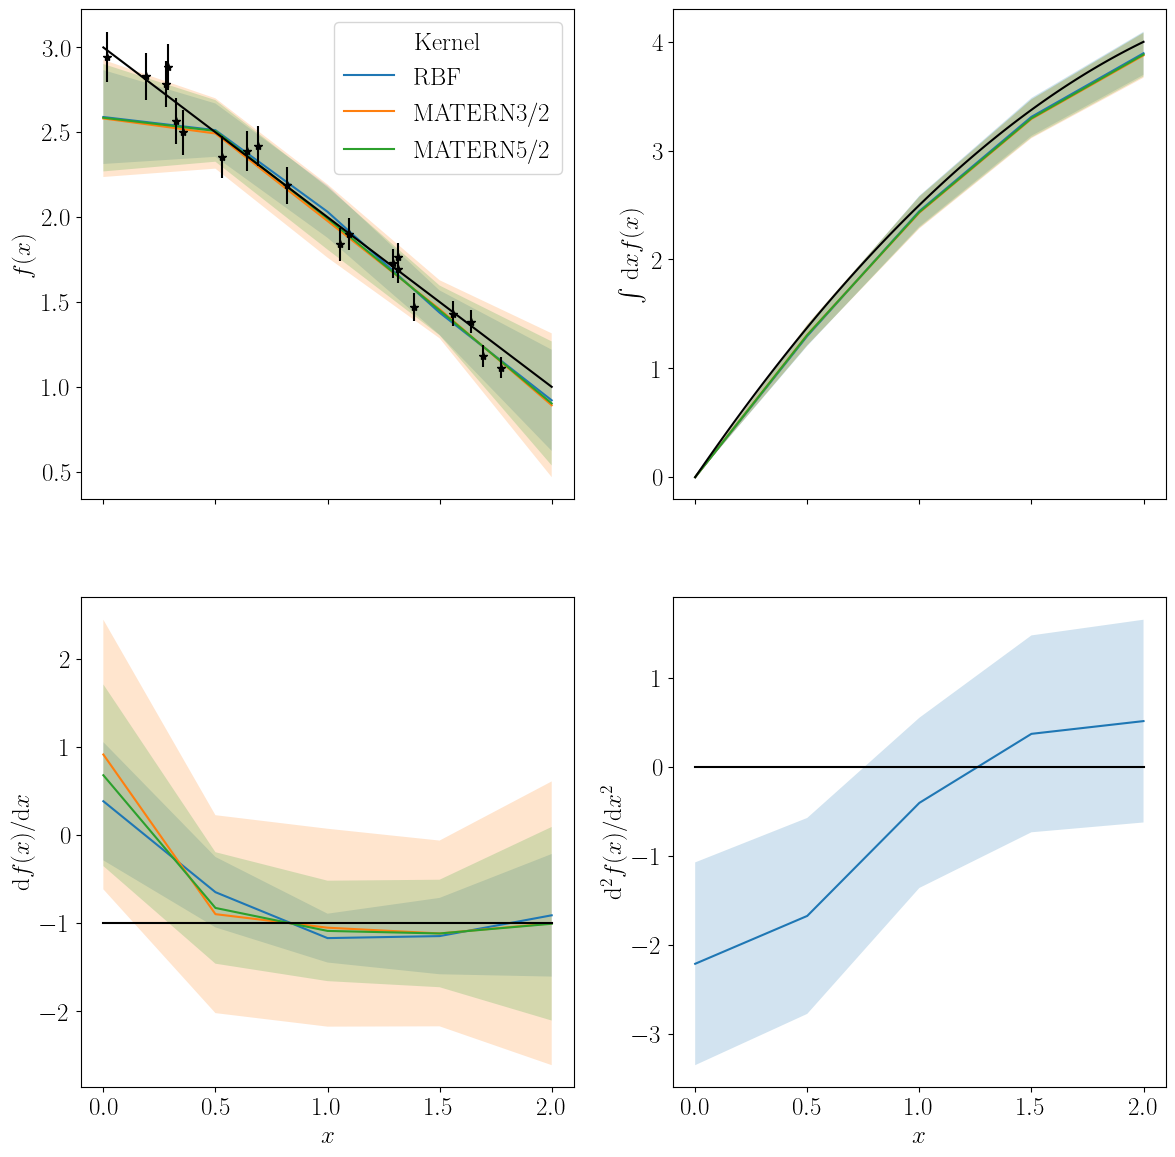

In [12]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for kernel in simple_GP['Kernel'].unique():
        df = simple_GP[simple_GP['Kernel']==kernel]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j])
    else:
        sb.lineplot(simple_GP,x='x',y=deriv,hue='Kernel',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Choosing hyper-parameters

The choice of hyper-parameters can be handled by the GPCalculator class, which offers the possibility
to switch between an optimization approach and a marginalization approach.

For this example we fix the kernel to RBF

In [13]:
reconstructions = {}

In [14]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF')

### Optimized

**Explain optimization here**

In [15]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Optimized'] = {'Functions': means,
                                'Covmat': joint_cov}

best_fit = info['Best-fit']

GP done in 19.63 s


### Marginalized

**Explain marginalization here**

In [16]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Marginalized'] = {'Functions': means,
                                   'Covmat': joint_cov}

sample = info['sample']

Removed no burn in
GP done in 820.08 s


### Visualize hyper-parameters

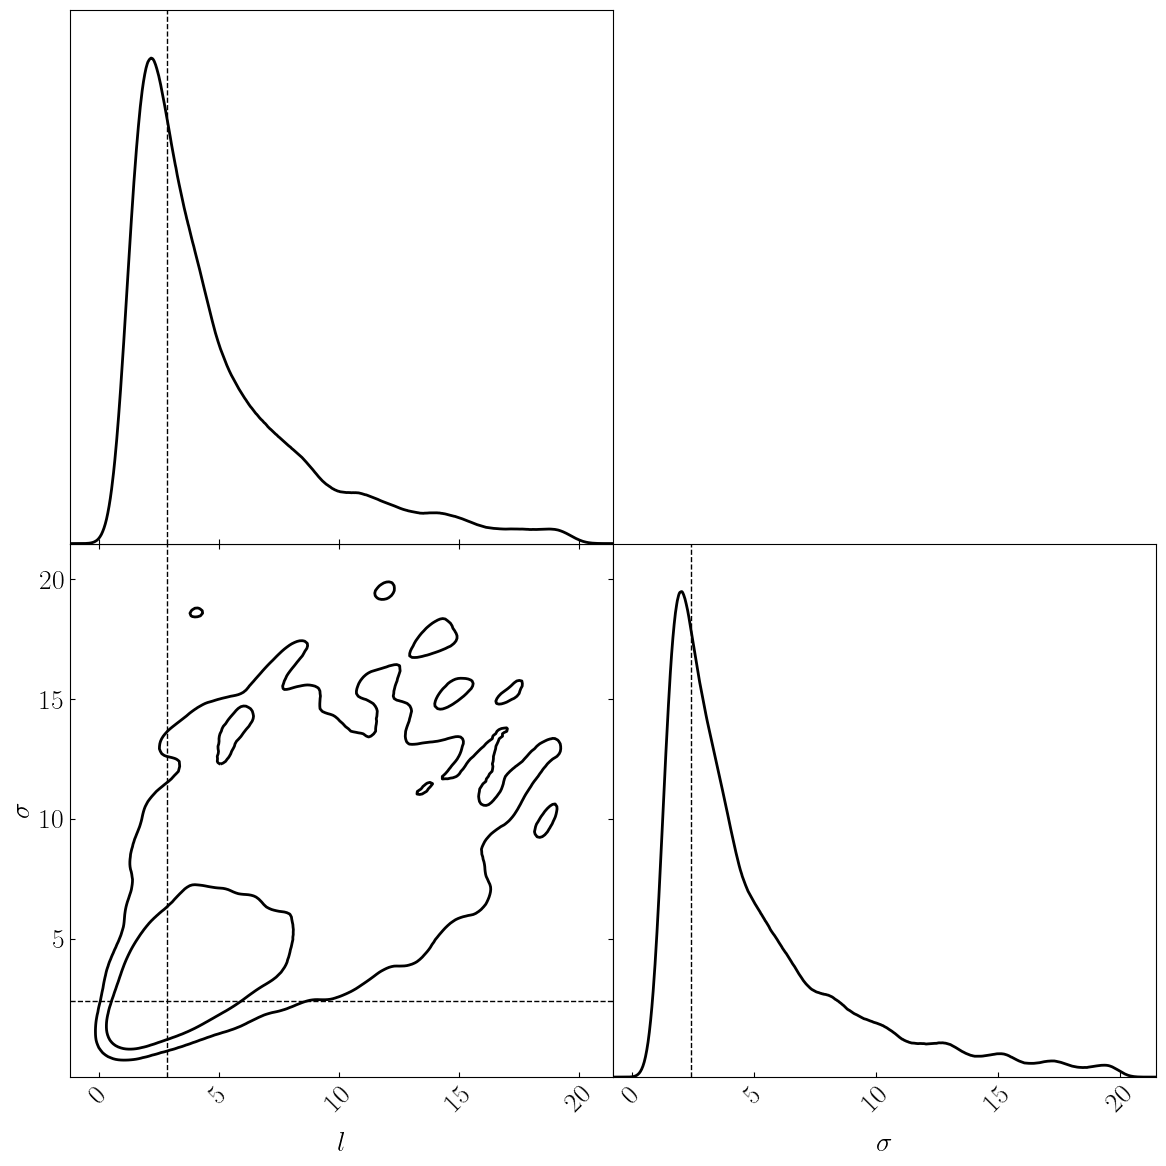

In [17]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['l','sigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Comparison

In [18]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

In [19]:
results

,x,f,d1,d2,int,f_err,d1_err,d2_err,int_err,Method
0,0.0,2.869027,-0.648724,-0.516425,0.000000,0.235322,0.376311,0.351049,0.000000,Optimized
1,0.5,2.485018,-0.876360,-0.385328,1.343261,0.142753,0.246180,0.377826,0.088968,Optimized
2,1.0,2.005558,-1.027033,-0.212370,2.469038,0.115666,0.183614,0.387044,0.140410,Optimized
3,1.5,1.473347,-1.085998,-0.023091,3.339972,0.125293,0.266017,0.374189,0.171221,Optimized
4,2.0,0.935126,-1.052017,0.154955,3.941356,0.231986,0.397820,0.345510,0.197954,Optimized
5,0.0,2.876411,-0.663900,-0.539500,0.000000,0.280772,0.607504,0.956577,0.000000,Marginalized
6,0.5,2.482198,-0.898886,-0.373705,1.344574,0.152086,0.305755,0.750035,0.097244,Marginalized
7,1.0,1.995774,-1.027724,-0.146879,2.466734,0.124545,0.214672,0.561855,0.148301,Marginalized
8,1.5,1.471270,-1.056104,0.024215,3.334059,0.128251,0.316481,0.661088,0.178482,Marginalized
9,2.0,0.952138,-1.009182,0.158795,3.938911,0.261988,0.534281,0.738857,0.204222,Marginalized


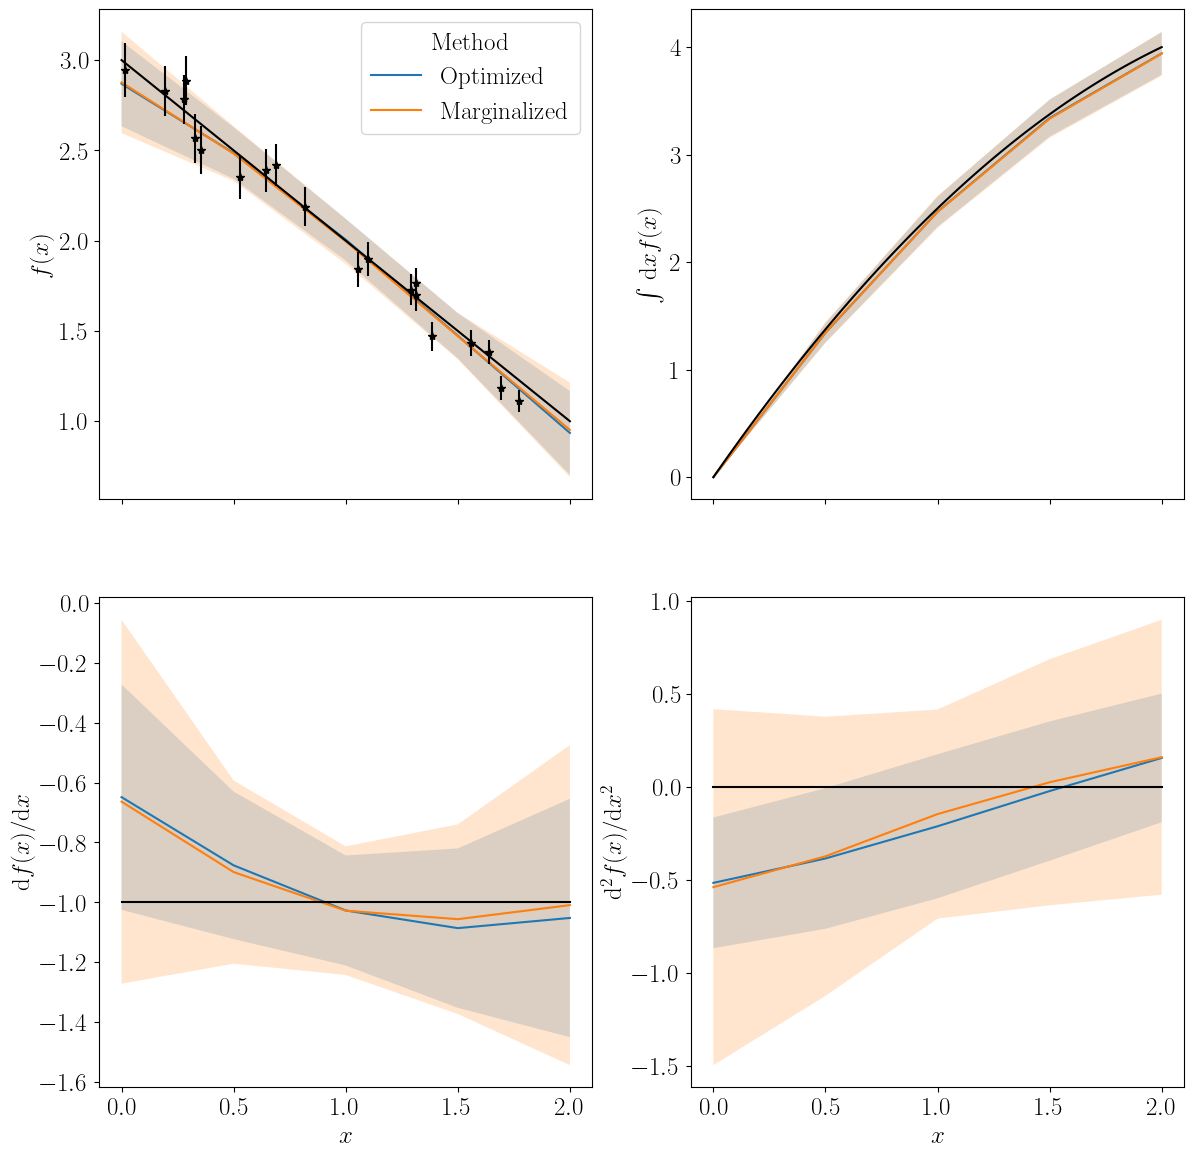

In [20]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    if theory_model != None:
        axes[i,j].plot(xplot,theory_model(xplot)[deriv],color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# GP diagnostics

**EXPLAIN DIAGNOSTICS HERE**

In [21]:
from tools.diagnostics import Scorer

In [22]:
score = {}

In [23]:
for k,v in reconstructions.items():
    score[k] = Scorer(v['Functions'],v['Covmat'],chatty=True)

## Theory score

Here we test against a fiducial function...

In [24]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory_model(x_recon)[func] for func in ['f','d1','d2','int']})

###  Malahanobis distance

Explain full $\chi^2$ and what we see here

In [25]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_theory(theory_df)


Optimized

 SCORE REPORT: THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 8.86
Red.  Chi2: 0.443
P-value:    0.9845
DOF:        20


Marginalized

 SCORE REPORT: THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 0.62
Red.  Chi2: 0.031
P-value:    1.0000
DOF:        20



### Diagonal distance

Explain diagonal $\chi^2$ and what we see here

In [26]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_pointwise(theory_df)


Optimized

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 5.73
Red.  Chi2: 0.286
P-value:    0.9992
DOF:        20


Marginalized

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status: GOOD (Consistent)
Total Chi2: 1.73
Red.  Chi2: 0.086
P-value:    1.0000
DOF:        20



## Comparison with data

In [27]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [28]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_data(datasets)


Optimized

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status: GOOD (Consistent)
Total Chi2: 3.48
Red.  Chi2: 0.174
P-value:    1.0000
DOF:        20


Marginalized

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status: GOOD (Consistent)
Total Chi2: 3.43
Red.  Chi2: 0.171
P-value:    1.0000
DOF:        20

